# 1. 군집화 (클러스터링)


## 1-1 비지도 학습

머신러닝은 지도학습과 비지도학습으로 나뉨. 
- **지도학습**: 문제와 정답을 모두 알려주고 학습 즉 예측값을 정답과 같아지도록  → 회귀, 분류
- **비지도학습**: 정답을 가르쳐주지 않고 학습 → 데이터 속 패턴/유사도를 스스로 찾음 → 군집화, 연관분석

비지도학습은 정답 레이블이 없어 목표가 명확히 정의되지 않고, **모델 성능을 명확히 측정할 수 없다**는게 특징. 다만 데이터에 내재된 구조·새로운 특성을 찾는 목적에는 적합.

**비지도학습이 언제 적합한가?**: 1. 패턴이 아직 알려지지 않은 경우 2. 패턴이 계속 변하는 경우 3. 열린 문제를 풀고 지식을 일반화해야 하는 경우

**활용 예**: 고객 세그먼트 분석, 이상 거래 탐지, nlp

## 1-2 군집화란?

**군집화**: 데이터를 비슷한 특성을 가진 그룹으로 나누는 비지도 학습 기법. 서로 다른 군집에 속한 개체들은 비슷하지 않아야 함.
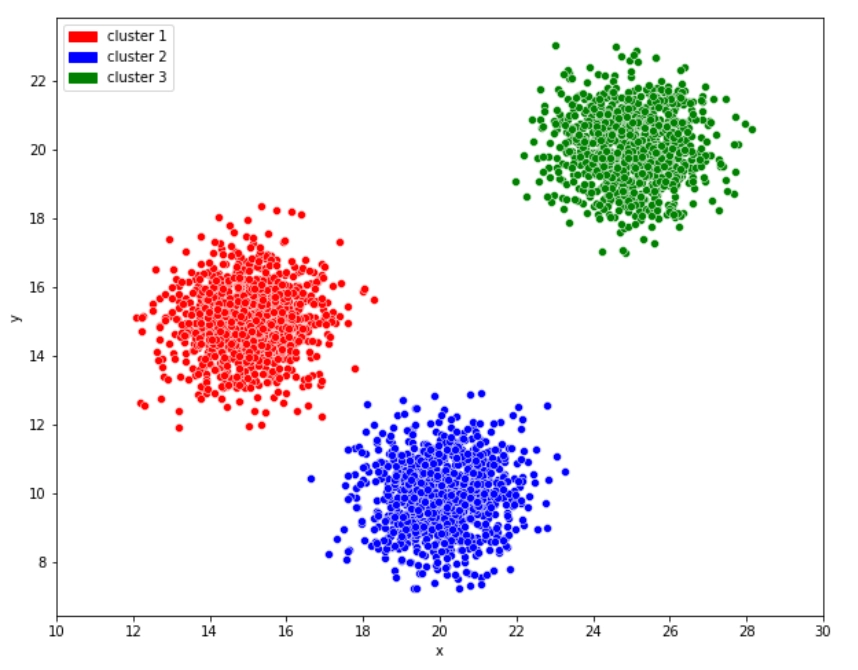

지도학습은 독립변수-종속변수 관계에서 패턴을 찾아 종속변수를 예측하지만, 군집화는 종속변수 없이 데이터 내부 패턴으로 유사 그룹을 나눔.

**군집화의 목표? **: **응집도 최대화** + **분리도(separation) 최대화** → 이 두 단어는 4장 평가 지표(실루엣 계수, 던 지수)의 계산 기준이 되므로 기억 -> 쉽게 말하면 같은 군집안에서 개체들은 가까이 모여있고(같은 군집내 동질성up) 다른 군집들과는 멀리 떨어져있는 것(다른 군집들간 이질성up)

## 1-3 군집화 과정 

1. **피처 선택/추출** — 사용할 데이터의 특징 선택 
2. **군집화 알고리즘 선택** — 데이터 특성·목표에 맞는 알고리즘 선택 
3. **군집 유효성 검증** — 군집화가 잘 됐는지 평가 
4. **결과 해석** — 각 군집의 특성 분석·해석 

군집화는 한 번에 끝나지 않고, 3단계에서 평가해보고 마음에 안 들면 다시 1단계(피처/알고리즘/k 변경)로 돌아감.


# 2. 군집화를 위한 데이터 준비 

## 2-1 주요 고려사항
1. **변수 유형 이해** — 연속형/명목형에 따라 적합한 알고리즘이 다름
2. **거리/유사도 정의** — 변수 유형에 따라 적합한 거리 측정 방식이 다름
3. **차원 축소** — 변수가 많아지면 모델이 복잡해지고 성능 저하

## 2-2 변수 유형

| 유형 | 예시 | 거리 측정 | 알고리즘 |
| --- | --- | --- | --- |
| 연속형 | 키, 몸무게, 나이, 소득 | 유클리디안, 맨하탄 | k-means, 계층적 |
| 명목형 | 성별, 지역, 직업 | 해밍, 자카드 | K-modes, 계층적(전용 거리함수) |
| 혼합형 | 연속형+명목형 | Gower distance | K-prototypes, 계층적 |

연속형은 **스케일링 필수** (단위가 다르면 큰 값의 변수가 거리를 지배).

**왜 유형마다 달라질까?**
- **거리는 "빼기가 말이 되는가"의 문제.** 지역을 서울=1/부산=2/대구=3처럼 숫자로 바꿔 유클리디안 거리를 재면 "서울-대구가 서울-부산보다 2배 다르다"는 이상한 순서나 간격이 생겨버림. 연속형(나이 25 vs 27)은 순서·간격 둘 다 의미 있어 빼기가 가능하지만, 명목형은 둘 다 없어 "같다/다르다"만 셀 수 있다 → 그래서 명목형은 해밍/자카드처럼 세는 방식의 거리를 씀. 혼합형은 Gower distance.

- **알고리즘은 평균이 말이 되는가의 문제.** 성별을 남=0/여=1로 두고 k-means를 돌리면 중심점이 "성별=0.6"처럼 나옴 이건 의미가 없다. k-means는 중심점을 평균으로 계산하므로 평균이 안 되는 변수엔 못 씀. K-modes는 modes니까 평균 대신 최빈값을 쓰고 K-prototypes는 연속형엔 평균·명목형엔 최빈값을 섞어 씀.

## 2-3 거리 측정 방법

- **유클리디안 거리**: $d(\mathbf{x},\mathbf{y})=\sqrt{\sum(x_i-y_i)^2}$ — 가장 일반적, K-means 기본값
- **맨하탄 거리**: $d(\mathbf{x},\mathbf{y})=\sum|x_i-y_i|$ — 이상치에 덜 민감
- **코사인 유사도**: $\frac{\mathbf{x}\cdot\mathbf{y}}{||\mathbf{x}||\times||\mathbf{y}||}$ — 벡터 간 각도 측정, 텍스트/고차원 데이터에 효과적


## 2-4 차원 축소

**차원의 저주**: 피처 공간이 너무 커서 알고리즘이 효과적으로 훈련할 수 없는 현상. 고차원일수록 모든 점이 비슷하게 멀어져 거리 기반 알고리즘의 분별력이 감소.

**왜 분별력이 사라짐?**
- 데이터 1,000개 고정 상태에서 차원이 늘어날수록 공간이 폭발적으로 커짐(축마다 10배씩) 
- 실제로 1,000개 점을 뿌려보면 가장가까운 애와 가장 먼 애의 거리 비율이 2차원에서 61배 차이 나던 것이 1000차원에서는 1.1배로 좁혀짐 → 가까운 점이나 먼 점이나 거의 똑같이 멀어져버려서 가까운 것끼리 묶어야한다는 그 기준 자체가 사라짐!
- 유클리디안 거리는 모든 차원의 차이를 모조리 더하므로 실제로 중요한 피처에 상관없는 피처가 많이 섞이면 그 무작위 차이들이 진짜 신호를 덮는다 → 피처는 많을수록 좋은 게 아니라 줄일수록 군집이 선명

**차원 축소**: 변수 개수를 줄이면서 핵심 정보(분산)는 지키는 것. 노이즈를 줄여 패턴 학습에 유리해짐. <-얘네도 너무 줄이면 왜곡되니 주의
- **선형 투영**: PCA, SVD, 랜덤 투영 등
- **매니폴드 학습(비선형)**: t-SNE, UMAP, Isomap 등 — 유클리드 거리가 아닌 곡선 거리를 고려


**PCA란 ? **: 다차원 데이터에서 정보량(분산)이 가장 큰 방향을 찾아, 그 방향 기준으로 데이터를 투영해 차원을 줄이는 것. 새로 파생된 성분을 **주성분**이라 함.

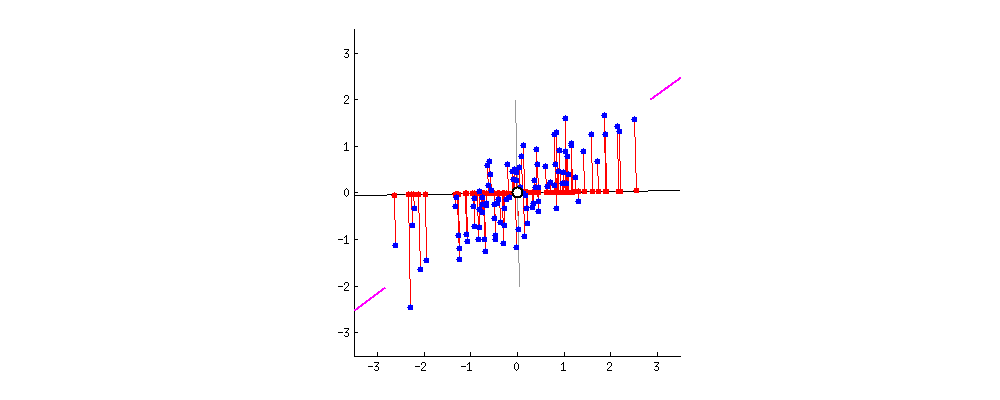

**진행 과정**: 1 공분산 행렬 계산 2 고유값 분해 3 고유값 높은 상위 k개 고유벡터 선택 4 데이터 투영

```python
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X)   # 평균0/분산1로 스케일링
pca = PCA().fit(X_scaled)                      # n_components 없이 일단 전부 학습
print(pca.explained_variance_ratio_)           # 각 주성분이 설명하는 분산 비율
```

예: 출력이 `[0.465, 0.309, 0.112, 0.065, 0.032, 0.017]`이면
- 2개 사용 시 77.3%(0.465+0.309) 정보 보존
- 90% 이상 원하면 3개까지는 88.6%로 부족 → 4개 필요
- 6개 대신 3개 사용 시: 정보 22.7% 손실, 대신 그림으로 그릴 수 있게 됨 3차원이라서

```python
pca = PCA(n_components=0.9)   # 분산 90%가 될 때까지 자동으로 개수 결정
X_pca = pca.fit_transform(X_scaled)
print(pca.n_components_)      # 실제 선택된 주성분 개수
```

**PCA 주의사항**: 1 표준화 필수 2 결측값 있으면 사용 불가 3 주성분은 원본 특성의 조합이라 해석이 어려움 4 차원 축소 과정에서 일부 정보 손실


# 3. 군집화 알고리즘 

## 3-1 계층적 군집화 

가장 가까운 것부터 둘씩 차례로 합쳐가며, 무엇이 언제 뭉쳤는지를 나무 모양(덴드로그램)으로 기록하는 방법. 

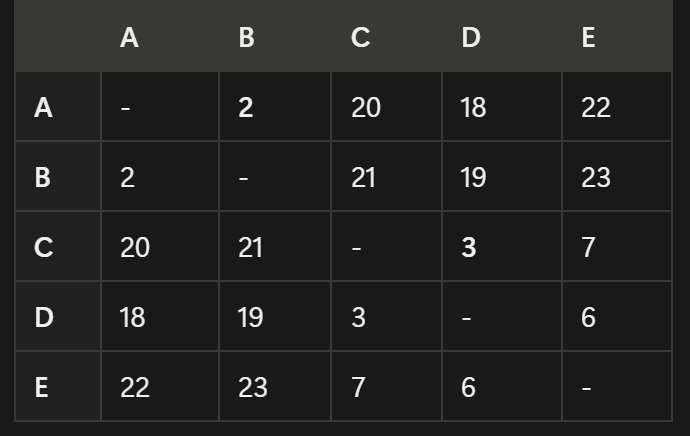
**손 계산 example**: 점 A~E의 거리표에서 가장 작은 값부터 합침 → A+B(거리 2) → C+D(거리 3) → {C,D}와 E 중 어느 거리를 쓸지가 문제(C-E=7, D-E=6) → 가장 가까운 두 점이 기준이면 6 → {A,B}+{C,D,E}는 18. 최종 병합 순서: 2→3→6→ 18.

**특징**
- 관측치로 **덴드로그램** 생성 (수직축 높이 = 병합될 때 군집 간 거리)
- 군집 개수를 사전에 정하지 않아도 됨(장점).
- **응집형(상향식)**: 각 샘플이 독립 클러스터로 시작해 하나로 합쳐감 
- **분리형(하향식)**: 전체 하나의 클러스터에서 시작해 나눔

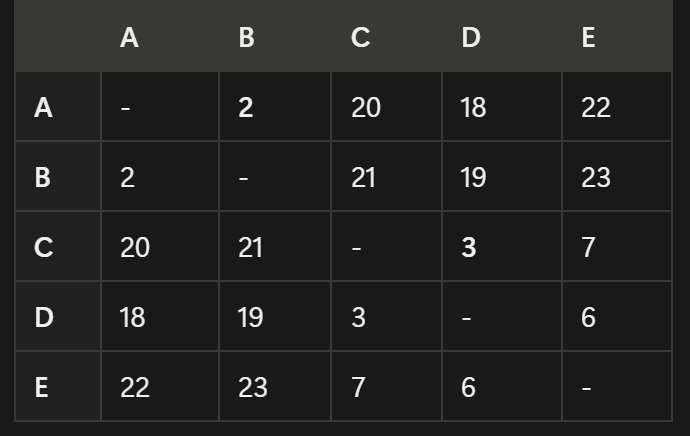

**응집형 과정**: 1 거리 행렬 계산 2 각 데이터를 개별 클러스터로 초기화 3 가장 가까운 두 클러스터 병합 4 거리 행렬 업데이트 5 하나가 될 때까지 반복

**6가지 연결방법** — 군집 간 거리를 어떻게 정의할까
1. **Single(단일)**: 두 군집 중 가장 가까운 두 점 간 거리. 고립된 군집 탐색에 강하지만 이상치에 취약
2. **Complete(완전)**: 가장 먼 두 점 간 거리. 내부 응집성에 중점, 이상치에 민감
3. **Average(평균)**: 모든 점 쌍 거리의 평균. 이상치에 덜 민감하지만 계산량 많음
4. **Centroid(중심)**: 두 군집 중심점 간 거리. 계산 오래 걸리고 덴드로그램에서 inversion 발생 가능
5. **Median(중앙)**: 두 군집 중심점의 산술적 중간지점을 새 대표값으로. 극단값에 덜 민감하지만 기하학적 구조 파악은 어려움 
6. **Ward**: 병합 후 군집 내 SSE 증가 최소인 병합 선택.

**덴드로그램 읽는 법**: 세로축=합쳐진 높이(군집 간 거리) / 낮게 붙을수록 가까움 / 긴 세로 막대=그만큼 멀어질 때까지 합칠 상대가 없었다는 뜻(진짜 경계란 뜻임)

**자르는 위치**: 가로선을 그어 끊는 세로선 개수가 군집 개수. 정석은 **가장 긴 세로 구간을 가로지르게** 자르는 것 why?- 그 구간이 길수록 위아래가 서로 다른 세계라는 신호이기 때문.

```python
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(X_scaled, method='ward')               # 병합 기록 계산, method가 연결법 선택
dendrogram(Z)                                      # 나무 그림으로 
labels = fcluster(Z, t=2, criterion='maxclust')    # 2개 군집으로 잘라 레이블 추출
```
`Z`를 한 번 만들면 `fcluster`의 `t`만 바꿔 2개 3개 5개 결과를 즉시 꺼낼 수 있음 (k-means는 매번 재학습 필요).

**장점**: k를 미리 안 정해도 됨 / 데이터 구조 전체가 눈에 보임 / 거리만 정의되면 어떤 데이터 유형에도 적용 가능 / 랜덤 초기화가 없어 결과가 항상 같음
**단점**: 느리고 메모리 많이 먹음 / 한 번 합치면 되돌릴 수 없음 / 이상치에 민감(특히 단일·완전연결) / 자르는 높이를 사람이 정해야 함

→ 실무에서는 **덴드로그램으로 먼저 k를 가늠해보고 그 값으로 k-means로 돌리는 조합**을 자주 사용.

## 3-2 k-means(비계층적 군집화)

데이터를 정해진 개수(K)의 그룹으로 나누되, 각 그룹의 **중심점**과 가장 가까운 데이터끼리 묶는 알고리즘. 가장 일반적으로 쓰임. 중심을 구할 수 없는 데이터에는 사용 불가.

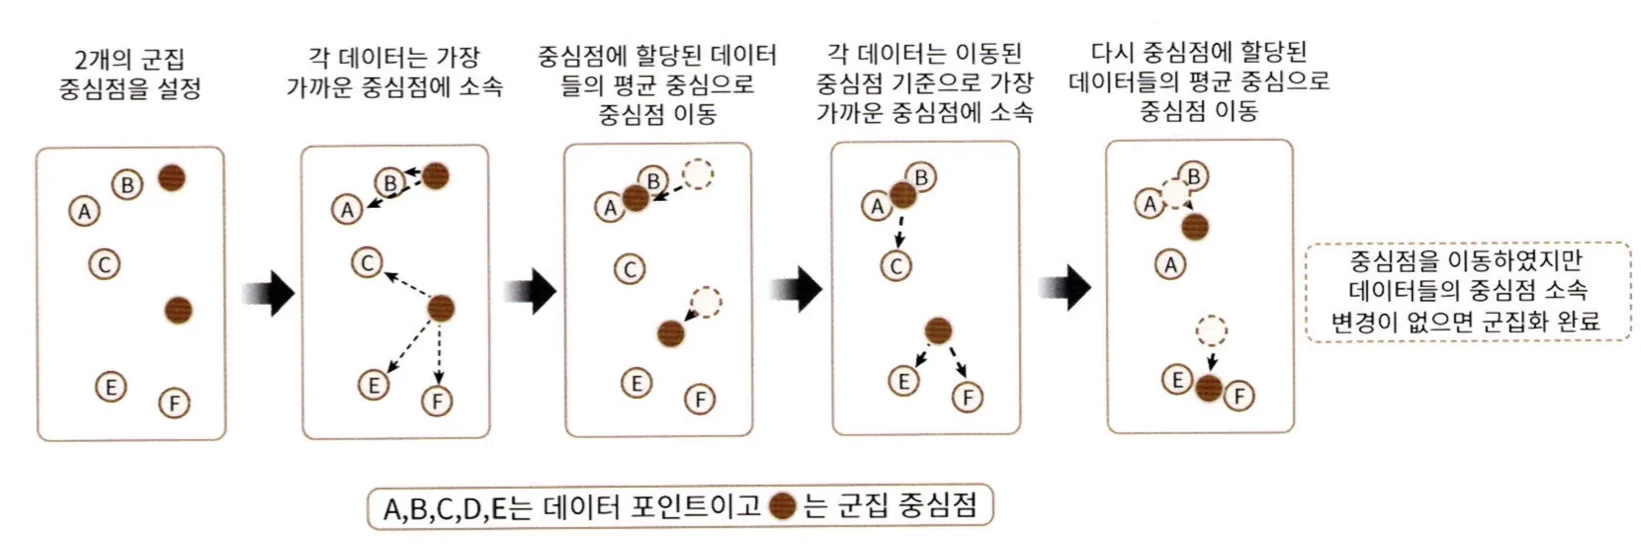

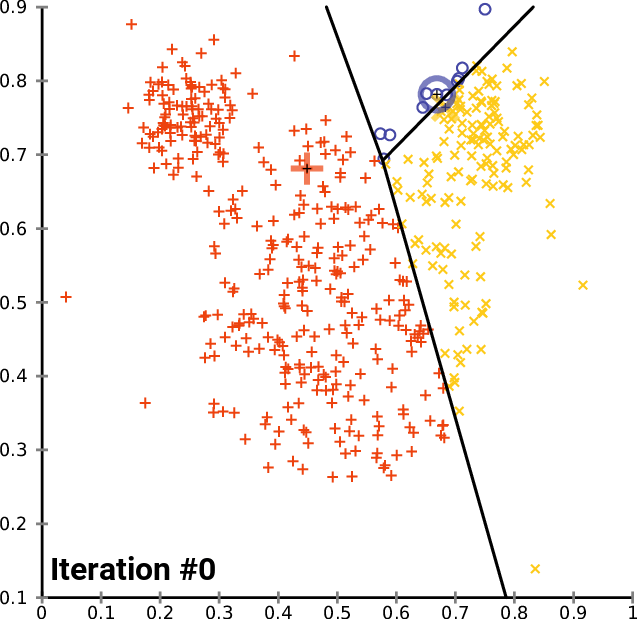

그림이나 짤로 파악하는게 제일 쉬움

**단계**: 1 랜덤하게 k개 중심점 선택 2 각 표본을 가장 가까운 중심점에 할당 3 할당된 표본들의 평균으로 중심점 이동 4 할당이 안 변하거나 최대 반복 도달할 때까지 반복

k-means는 군집 내 sse를 최소화하는 것이 목표
```python
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3,          # 군집 개수 지정함
                init='k-means++',      # 초기 중심점을 서로 멀리 배치
                n_init=10,             # 다른 초기값으로 10번 돌려 최적 채택
                random_state=42)       # 난수 시드 고정
labels = kmeans.fit_predict(X_scaled)  # 몇번 군집인지 반환
```
 `X_scaled`를 쓰는 이유?: 유클리디안 거리를 쓰므로 스케일이 다르면 큰 값의 피처가 거리를 지배하기 때문.

**장점**: 직관적, 구현 쉬움 / 대용량 데이터에도 적용 가능
**단점**: 초기 centroid에 민감(k-means++로 완화) / 군집 수 k 결정이 어려움(엘보우, 실루엣으로 탐색) / 평균 기반이라 이상치에 민감 / 길쭉하거나 초승달 모양의 군집은 잘 못 잡음


**엘보우 방법(팔꿈치 기법)**: k를 바꿔가며 SSE를 그래프로 그려, 기울기가 급격히 꺾이는 지점(팔꿈치)을 최적 k로 삼음 — 그 이후엔 k를 늘려도 SSE 감소 효과가 미미하기 때문. 
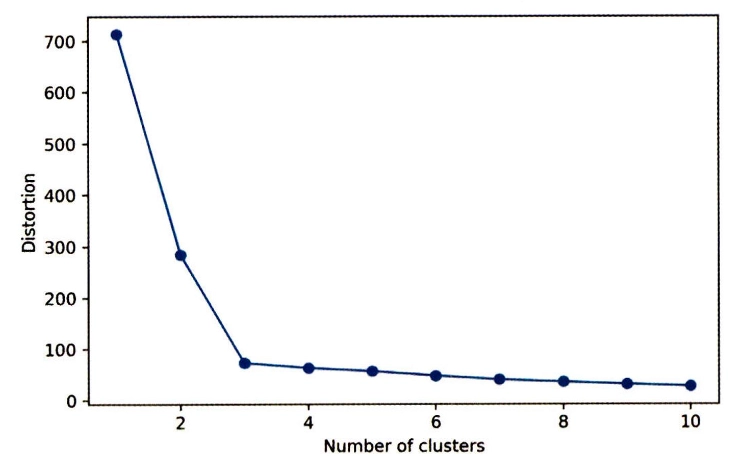

k=3일때를 고르면 되겠죠?

하지만 그래프가 완만하면 잘안보이니 실루엣계수도 같이 봐야함.

## 3-3 DBSCAN(비계층적 군집화)

밀도가 높은 지역의 데이터를 하나의 군집으로 묶고, 밀도 기준을 만족하지 못하는 점은 군집에 포함시키지 않는 군집화 알고리즘.
k means와 달리 k를 안 정해도 되고, 이상치를 따로 빼고, 모양을 안 가림
**샘플 분류**
- **핵심 샘플**: 반경 ε 안 이웃이 MinPts 이상
- **경계 샘플**: ε 이내 이웃은 부족하지만 다른 핵심 샘플의 ε 안에 있음
- **잡음 샘플**: 위 둘 다 아닌 나머지

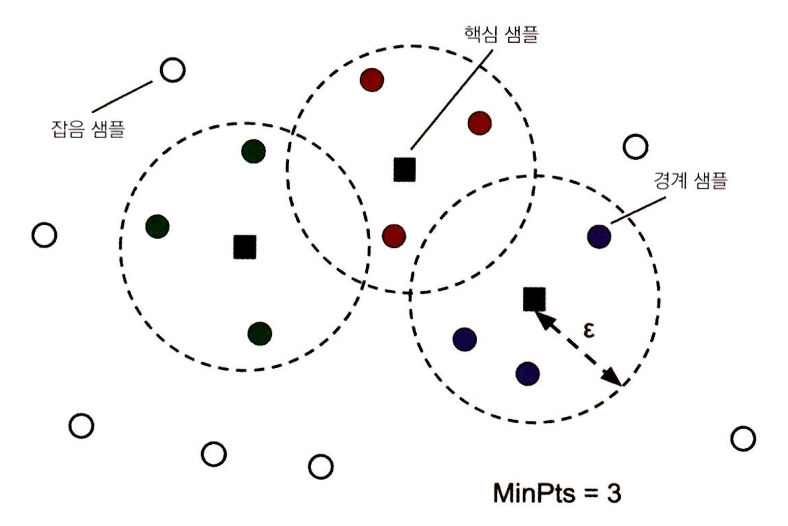

**단계**: 1 샘플 분류 2 핵심 샘플들을 ε로 연결한 그룹을 클러스터로 생성 3 경계 샘플을 해당 핵심 샘플의 클러스터에 할당

```python
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5,          # 이웃으로 인정할 최대 거리 
            min_samples=5)    # 군집 인정을 위한 최소 점 개수
labels = db.fit_predict(X_scaled)
print((labels == -1).sum())   # -1(이상치)로 분류된 개수
```
DBSCAN은 군집 수를 사람이 정하지 않는 대신 **밀도 기준**을 정해야 함 근데 이게 더 어려울 수 있는 이유는?: 
1 k는 감이 오지만 eps는 데이터를 보기 전엔 의미x 2 스케일에 종속적(표준화 방식에 따라 같은 값이 다른 뜻 됨) 3 군집마다 밀도가 다르면 하나의 eps로 못 잡음 — DBSCAN의 구조적 한계.

**장점**: 임의의 기하학적 분포 처리 가능(원형 가정 안 하기 때문) / 노이즈로 이상치 검출 가능 / 모든 샘플을 클러스터에 강제 할당하지 않음
**단점**: eps, min_samples 설정 잘해야함 / 연산량 많아 느림 / 밀도가 다른 군집들은 잘 못 잡음(밀도 낮은 쪽을 통으로 노이즈로 버려버림) / 차원의 저주 영향 받음


## 3-4 Gaussian Mixture Model (비계층적 군집화)

데이터가 여러 다른 모양의 가우시안 분포로 구성되었다고 가정하고, 각 분포를 클러스터로 인식하는 방법. 
if k-means가 "이 점은 1번 군집"이라 딱 잘라 말할때 GMM은 "70% 확률로 1번, 30%로 2번"처럼 **확률**로 답함.

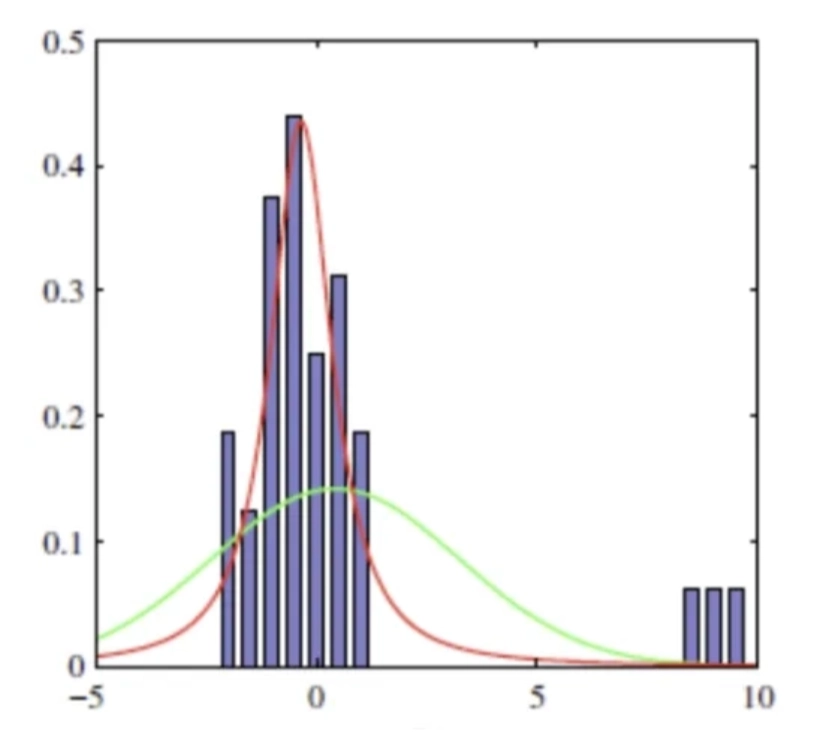

**특징**: 모델 기반 군집화(통계적 모델가정) / 각 군집을 확률 분포로 간주, 전체를 여러 분포의 혼합으로 모델링 / 데이터 생성 메커니즘까지 모델링 가능

**진행**: 1 전체 데이터셋 분포 확인
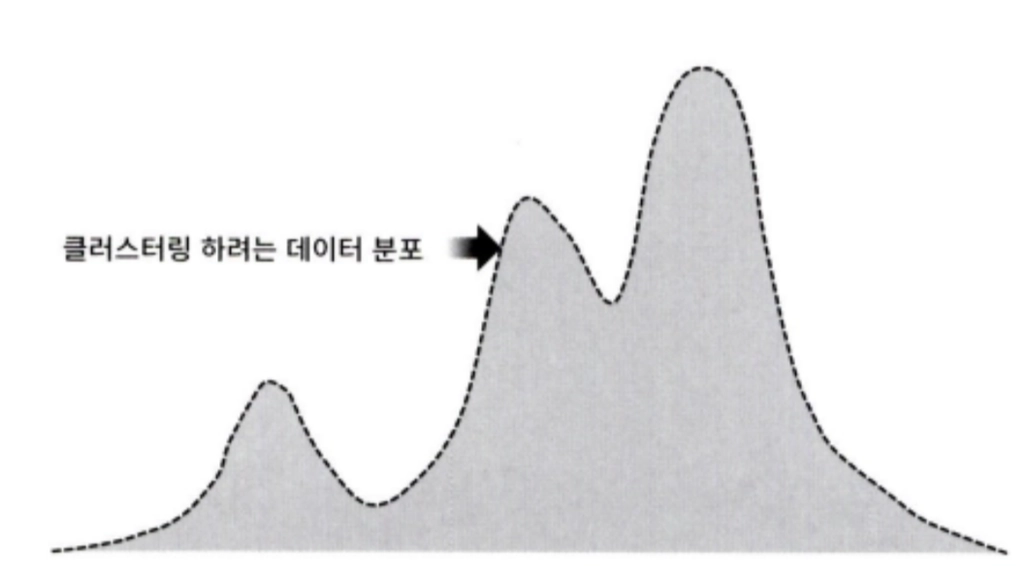 
2 서로 다른 정규분포 곡선들로 구성되어 있다고 가정 
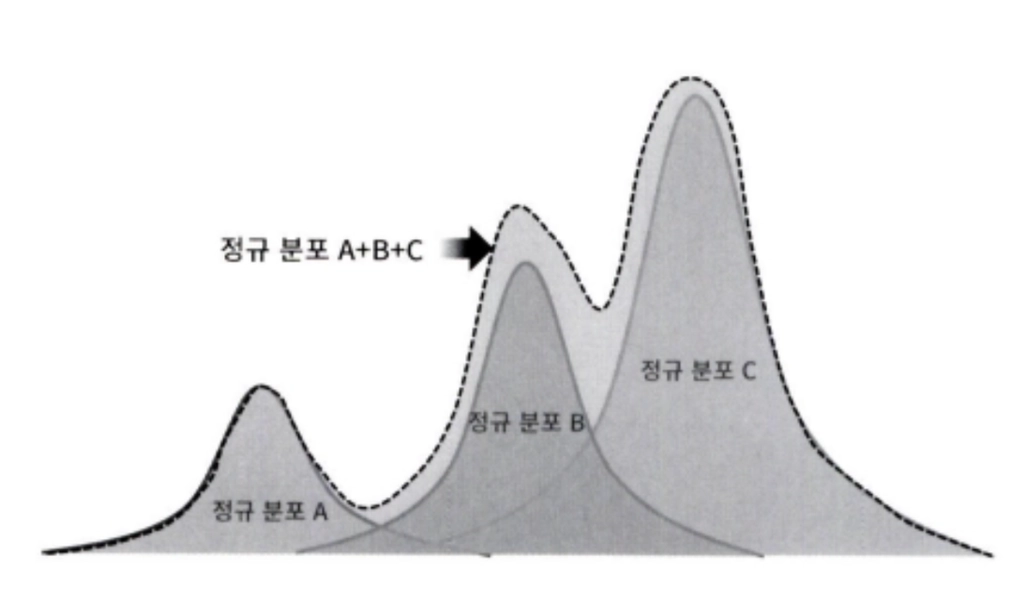
3 여러 정규분포 곡선을 추출해 개별 데이터가 속하는 분포를 결정(각 분포=하나의 군집)
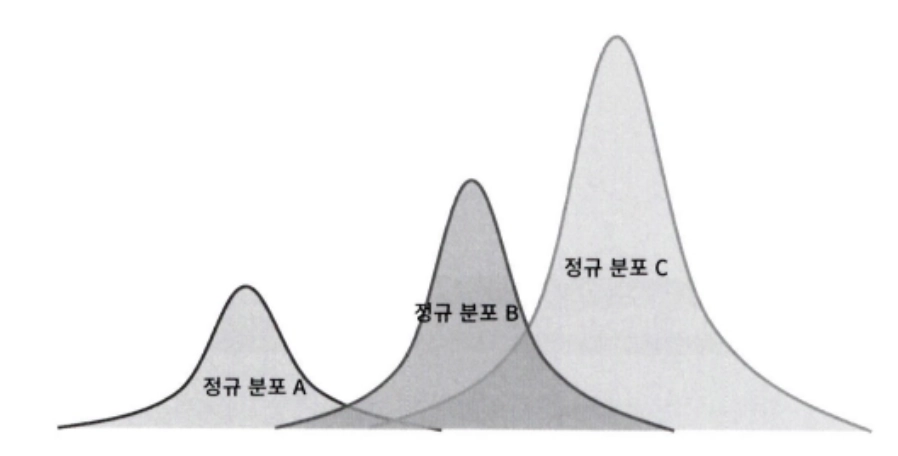

파라미터는 **EM 알고리즘**으로 추정함

**K-means vs GMM**

| 구분 | K-means | GMM |
| --- | --- | --- |
| 기반 | 중심 기반 | 확률 분포 기반 |
| 할당 | hard(딱 하나) | soft(확률로 분산) |
| 장점 | 원형에 효과적, 빠름 | 다양한 형태에 유연, 길쭉/겹친 분포도 처리 |
| 단점 | 길쭉한 분포 최적화 어려움 | 오래 걸림, 정규분포 가정 필요 |

```python
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
labels = gmm.fit_predict(X_scaled)
proba = gmm.predict_proba(X_scaled)   # 각 군집에 속할 확률
```
ex: [0.05, 0.70, 0.25]는 어디 군집일까? → 2번째 군집에 가장 높은 확률로 속하지만, labels엔 그냥 `1`만 찍힘. 
GMM은 k-means가 못 주는 정보를 줌:  1 확신의 정도(같은 라벨이라도 [0.98]과 [0.70]은 다르다)  2 두 번째로 가까운 군집이 어디인지 3 임계값을 걸어 분류보류 처리하거나 따로 검토 가능. 

## 3-5 언제 어떤 알고리즘을 고를까?

| 상황 | 알고리즘 | 이유 |
| --- | --- | --- |
| 몇 개로 나눌지 감이 안 온다 | 계층적 | 덴드로그램 보고 나중에 자를 위치 결정 |
| 대체로 동글동글하고 데이터가 크다 | k-means | 빠르고 직관적, 대용량 무리 없음 |
| 모양이 길쭉하거나 겹친다 | GMM | 타원형·중첩을 확률로 처리 |
| 이상치를 골라내는 게 목적 | DBSCAN | -1로 명시적 분리 |
| 초승달·소용돌이처럼 이상한 모양 | DBSCAN | 모양 가정 없이 밀도로만 판단 |
| 군집마다 밀도가 제각각 | HDBSCAN | 단일 밀도 기준 한계 보완 |
| 경계에 걸친 애매함까지 알고 싶다 | GMM | predict_proba로 소속 확률 반환 |

**쓰지 말아야 할 때는?**: k-means는 이상치 많거나 군집 크기가 심하게 불균형할 때 / 계층적은 데이터가 수만 건 이상일 때 / DBSCAN은 피처가 수십 개 이상인 고차원일 때 / GMM은 정규분포와 거리가 멀 때 / 전부 스케일링 안 한 데이터에는 쓰면 안 됨.

현실적으론 하나만 고르진 않고, 보통 2~3개를 돌려본 뒤에 평가 지표로 비교해서 고름.


# 4. 군집화 평가 방법 

## 4-1 외부 평가와 내부 평가

**외부 평가**: 정답 레이블이 있는 경우 사용. 군집화 결과와 실제 레이블을 비교.
- **ARI?**: 군집화 결과와 실제 레이블 간 일치도를 측정함. 랜드 지수를 보완해 우연에 의한 일치 가능성을 배제. 값 범위 -1~1(보통 0~1), 1에 가까울수록 실제 레이블과 거의 일치, 0에 가까우면 무작위와 유사.


**내부 평가**: 정답 레이블이 없는 경우 사용. 응집도·분리도를 기반으로 데이터 자체의 구조로 품질을 정량화.
- 알고리즘별 지표: k-means는 SSE 최소화, GMM은 로그 우도 최대화
- 범용 지표: **실루엣 계수**, **던 지수** 

## 4-2 실루엣 계수 ?

클러스터 내 샘플들이 얼마나 조밀하게 모여 있는가?

$$s^{(i)}=\frac{b^{(i)}-a^{(i)}}{\max\{b^{(i)},a^{(i)}\}}$$

- $a^{(i)}$: 같은 클러스터 내 다른 포인트들과의 평균 거리 (응집도)
- $b^{(i)}$: 가장 가까운 다른 클러스터 샘플들과의 평균 거리 (분리도)

**해석** (-1~1 범위)
- 분리도 > 응집도 → 1에 가까움 → 군집화 잘 됨
- 분리도 = 응집도 → 0에 가까움 → 경계에 위치, 분리가 모호
- 분리도 < 응집도 → -1에 가까움 → 잘못됨

--> 평균 실루엣 계수가 보통 **0.5 이상이면 쓸만, 0.7 이상이면 잘 됨**으로 해석.

```python
from sklearn.metrics import silhouette_score, silhouette_samples

score = silhouette_score(X_scaled, labels)    # 전체 평균 
each  = silhouette_samples(X_scaled, labels)  # 샘플별 값 
```
평균만 보면 안 되는 이유: 평균이 같아도 한쪽은 모든 군집이 고르게 분포하고 다른 쪽은 특정 군집만 유독 낮을 수 있음 — 이때 당연히 전자를 고르는게 합리적임. 그래서 실루엣 그래프(얼마나 고른가?)로 함께 봐야 함.

## 4-3 Dunn Index

클러스터 간 최소 거리(분리도)와 클러스터 내 최대 거리(응집도)의 비율로 품질을 평가.

$$\text{Dunn Index}=\frac{\min_{i\ne j}d(C_i,C_j)}{\max_k \delta(C_k)}$$

- $d(C_i,C_j)$: 두 클러스터 간 거리(분리도) / $\delta(C_k)$: 클러스터 내 가장 먼 두 점 간 거리(응집도)

해석 : 값이 클수록 좋은 군집화(분리도up, 응집도up), 0 이상 값에 상한 없음. 실루엣 계수와 함께 종합 판단 권장.

**한계**: 군집 수가 많아질수록 계산 비용 증가 / 극단값(가장 먼 점 or 가장 가까운 군집)에 큰 영향 받음 / 이상치에 민감해 수치가 급격히 떨어질 수 있음



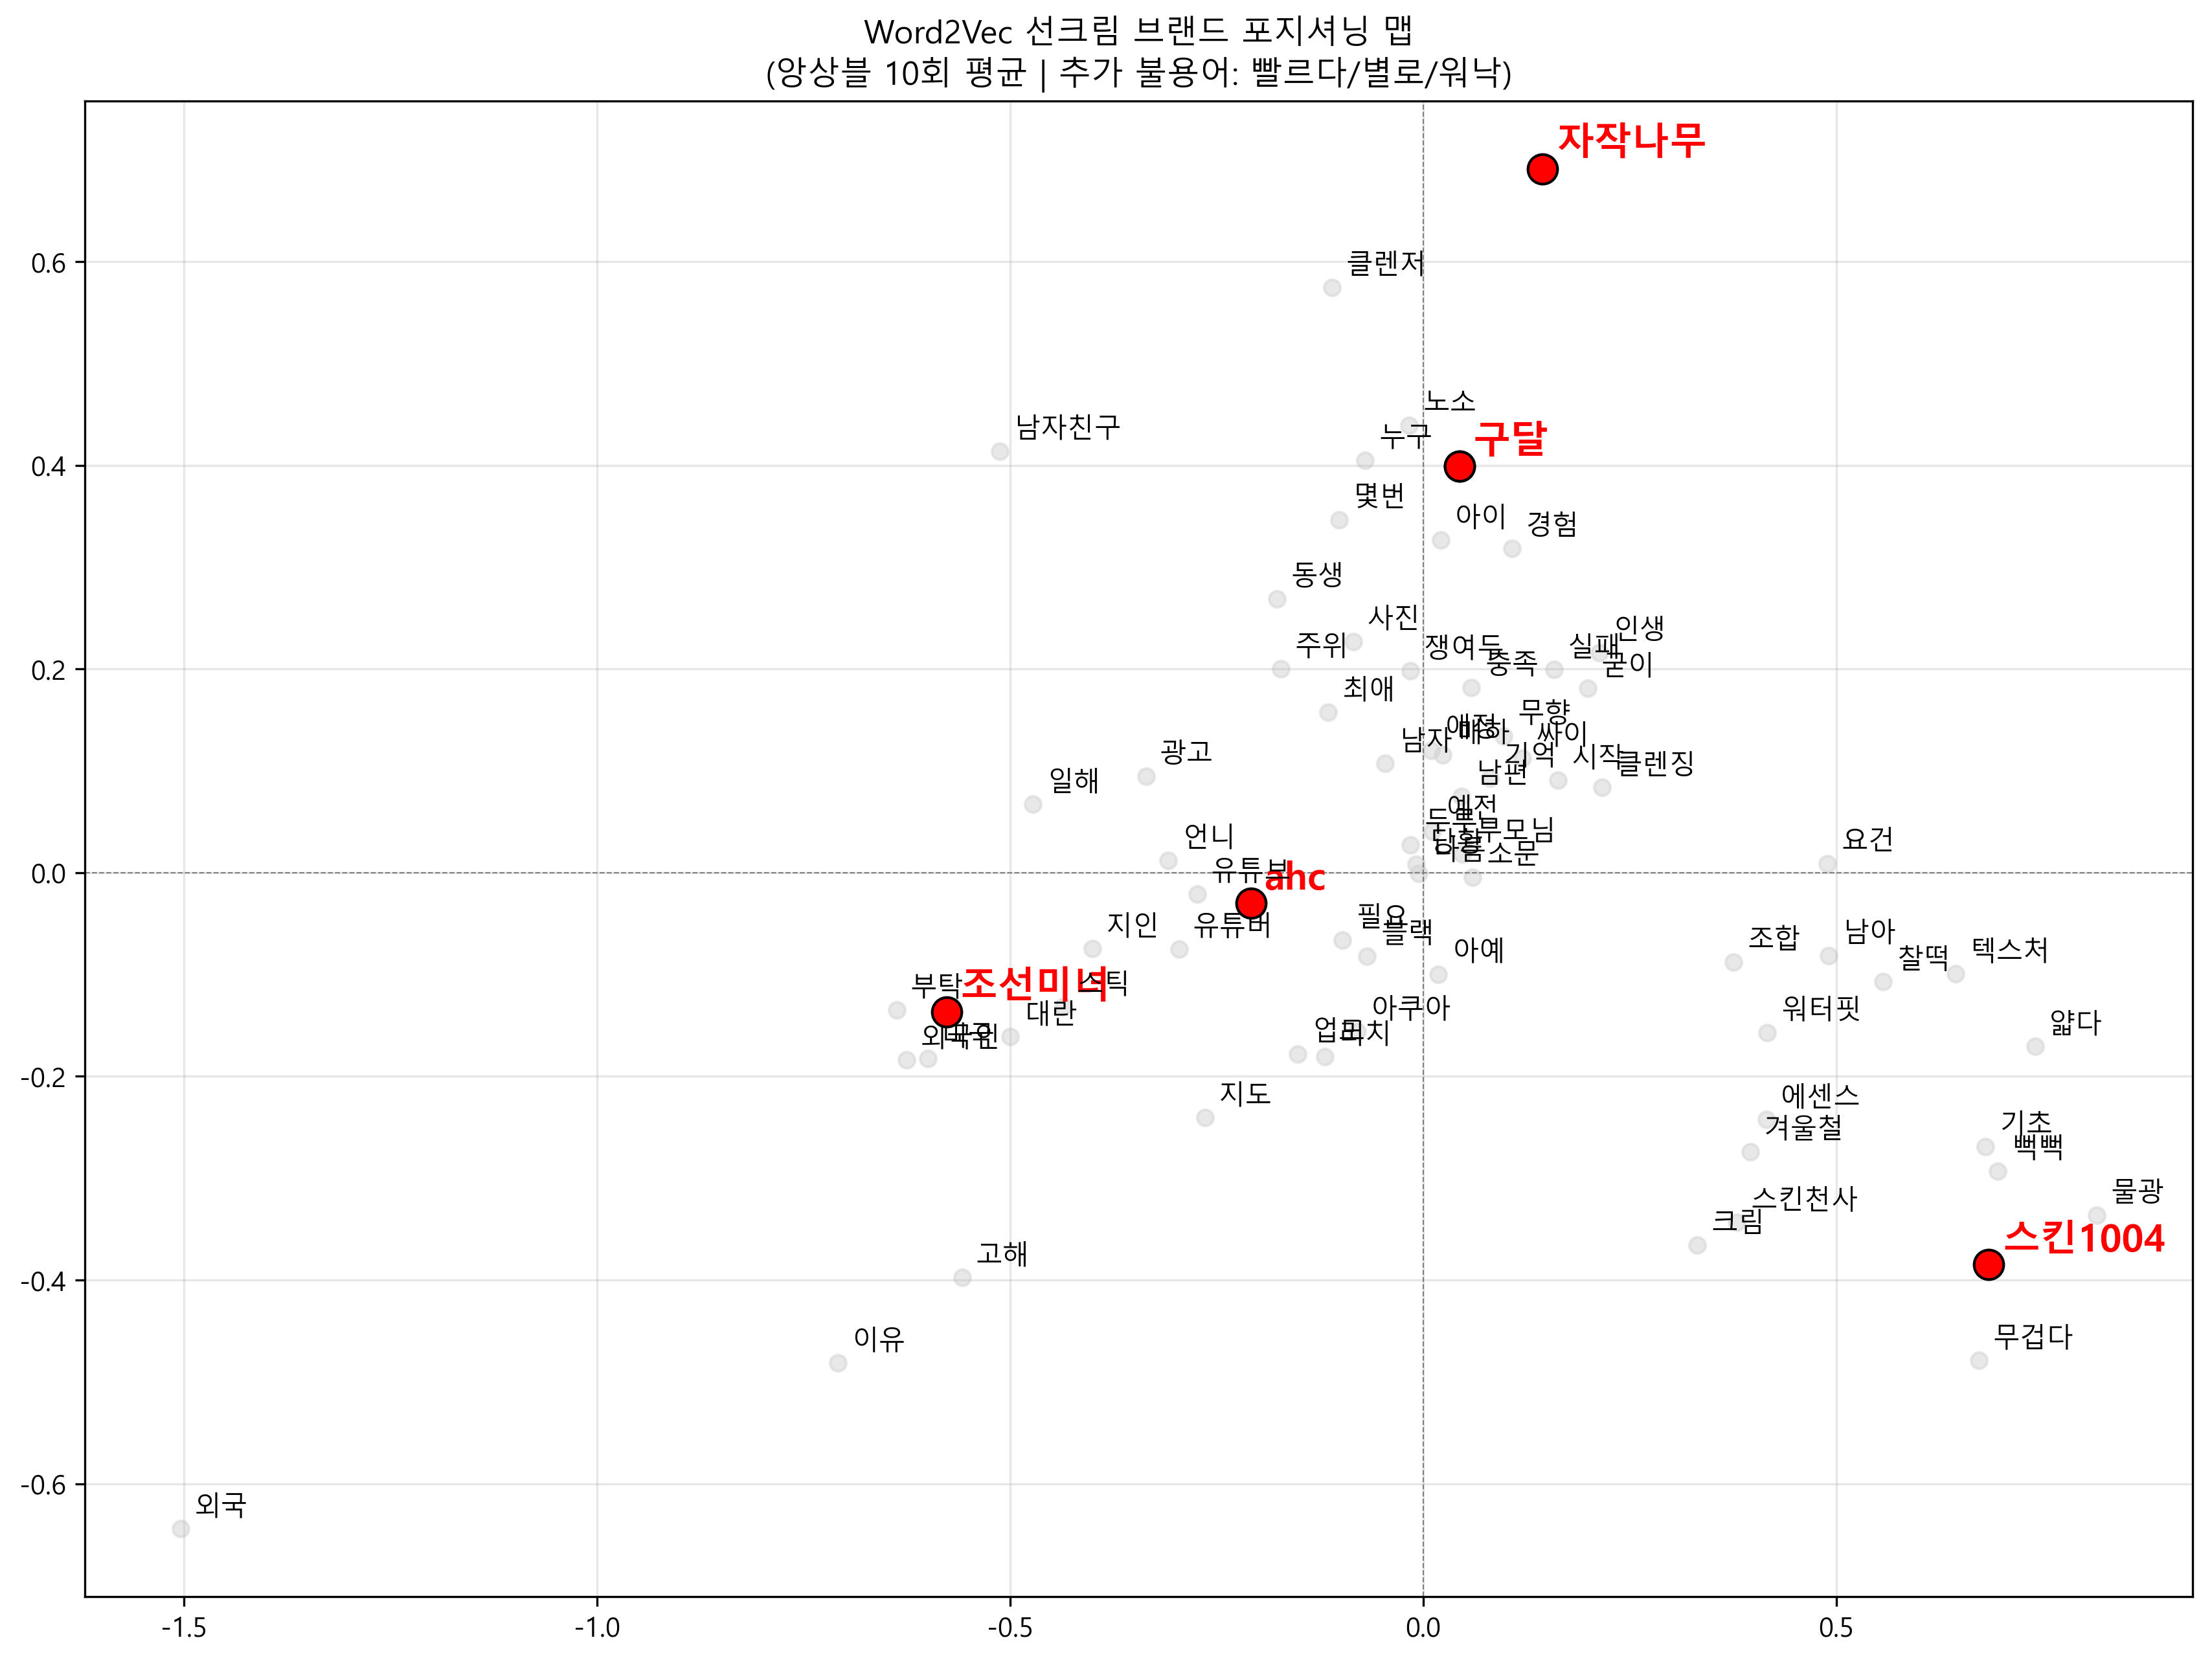

군집화를 이용한 분석들중 마케팅관리 팀플에서 선크림들 비교하는 세션에서 올리브영 후기들을 크롤링해서 w2v을 유클리드 거리기반의 포지셔닝 맵으로 만들어봤던 기억이 나서 첨부합니다

![스크린샷 2026-08-20 193531.png](<attachment:스크린샷 2026-08-20 193531.png>)

그뒤에는 자동으로 포지셔닝맵을 만들어주는 웹이 있으면 좋겠다고 생각을 해서 파일을 넣으면 자동으로 포지셔닝 맵을 만들어주는 거도 만들어 봤습니다. 이처럼 군집화 베이스의 여러 통계기법들이 많아서 중요한 내용이라고 생각합니다.
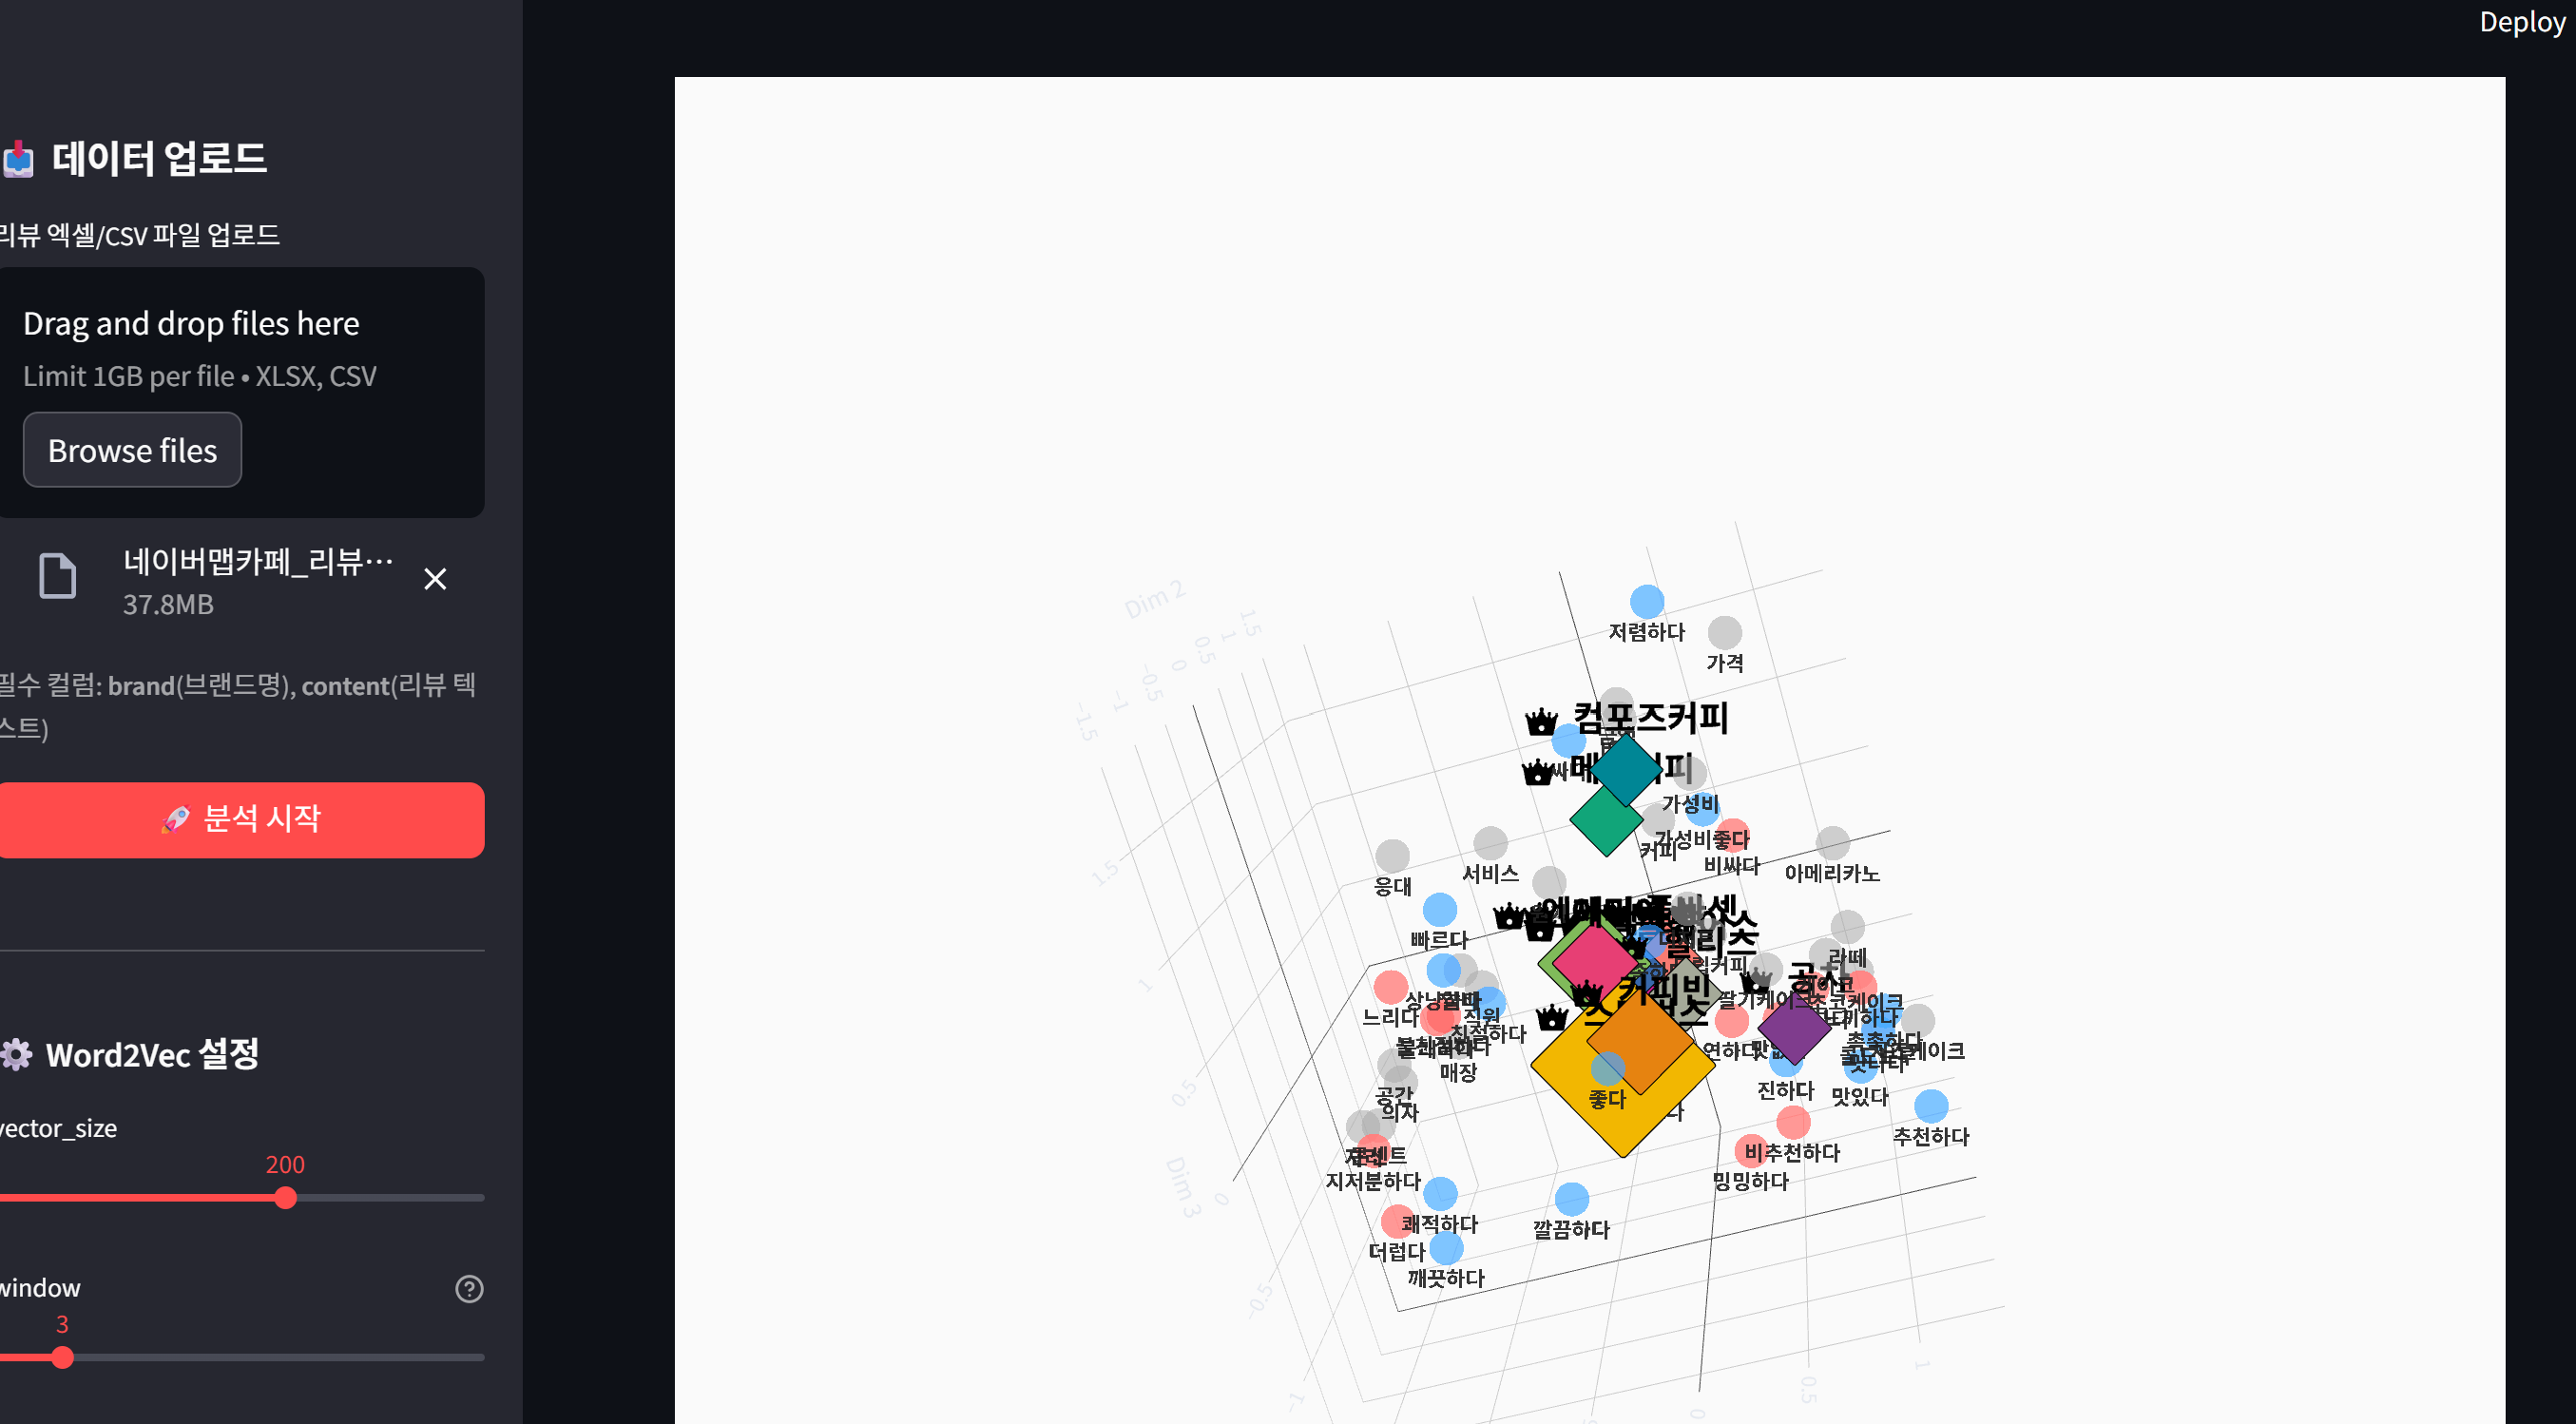